## Final Project

For this project, I will train and evaluate a model to predict customer churn for telecom operator Interconnect. In the first step of this project, I will perform some exploratory data analysis, and then outline a list of clarifying questions and work plan.

In [1]:
# Load and initialize libraries
import pandas as pd
import numpy as np
from numpy.random import RandomState
from matplotlib import pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [2]:
# Load datasets
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

In [3]:
# Look at info and sample for each dataset

print('--contract--')
print(contract.info())
print(contract.head())
print()

print('--personal--')
print(personal.info())
print(personal.head())
print()

print('--internet--')
print(internet.info())
print(internet.head())
print()

print('--phone--')
print(phone.info())
print(phone.head())


--contract--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
None
   customerID   BeginDate              EndDate            Type  \
0  7590-VHVEG  2020-01-01                   No  Month-to-month   
1  5575-GNVDE  2017-04-01                   No        One year   
2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00  Month-to-month   
3  7795-CFOCW  2016-05-01                   No        One year   
4  9237-HQITU  2019-09

There are no missing values in any of the four datasets. There are 7043 records in both the 'contracts' and 'personal' datasets, suggesting these cover the same set of customers. The total records in 'phone' and 'internet' add up to more than 7043, so some customers likely have both phone and internet services.

In [4]:

# Join contract and personal dataframes on ID column
contract_personal = pd.merge(contract, personal, on='customerID', how='outer')

# Call info
contract_personal.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 715.3+ KB


Confirmed--after doing an outer join with the contract and personal tables, we can see the number of records is the same, so these sets did cover the same set of customers and now all the info is in one table.

We'll continue joining with the phone and internet tables to combine all info in one place.

In [5]:
# Join with phone dataframe on ID column
contract_personal_phone = pd.merge(contract_personal, phone, on='customerID', how='outer')

# Call info
contract_personal_phone.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  MultipleLines     6361 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 770.3+ KB


In [6]:
# Join with internet dataframe on ID column
customer_info = pd.merge(contract_personal_phone, internet, on='customerID', how='outer')

# Call info
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  MultipleLines     6361 non-null   object 
 13  InternetService   5517 non-null   object 
 14  OnlineSecurity    5517 non-null   object 
 15  OnlineBackup      5517 non-null   object 
 16  DeviceProtection  5517 non-null   object 


Now all our data is one one dataframe, and we can see that we still have 7043 records, so there were no new customers in the 'phone' or 'internet' datasets. We now have some missing values, and these likely are because some customers with internet services do not have phone services and vice versa, but we'll hold off on filling in nulls until we get answers to our clarifying questions.

Before moving forward with EDA, we'll do some cleaning and transformation of columns to give us more useful information.

In [7]:

# Add a 'churned' column that will serve as the target column
customer_info['churned'] = (customer_info['EndDate'] != 'No').astype(int)


In [8]:
# Replace 'No' values in the 'EndDate' column with Feb 1, 2020
customer_info['EndDate'] = customer_info['EndDate'].replace(
    'No', '2020-02-01 00:00:00'
)


# Convert column to datetime
customer_info['EndDate'] = pd.to_datetime(customer_info['EndDate'])


In [9]:
# Convert 'BeginDate' column to datetime
customer_info['BeginDate'] = pd.to_datetime(customer_info['BeginDate'])

In [10]:
# Add a 'months_active' column
customer_info['months_active'] = (
    (customer_info['EndDate'] - customer_info['BeginDate']).dt.days / 30
)

Above, I added two columns: a 'churned' column that translated 'EndDate' values into a cleaner boolean format to serve as the target, and a 'months_active' column showing the customer's tenure. I eventually want to drop the 'BeginDate' and 'EndDate' columns in favor of this new column as I think it's sufficient to capture a potentially correlating feature (e.g., the longer a customer has been active, the less likely they are to churn) but will hold off until clarifying questions are answered.


In [11]:
# Drop  begin and end date columns
customer_info = customer_info.drop(columns=['BeginDate', 'EndDate'])

# Call info on current dataframe
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Type              7043 non-null   object 
 2   PaperlessBilling  7043 non-null   object 
 3   PaymentMethod     7043 non-null   object 
 4   MonthlyCharges    7043 non-null   float64
 5   TotalCharges      7043 non-null   object 
 6   gender            7043 non-null   object 
 7   SeniorCitizen     7043 non-null   int64  
 8   Partner           7043 non-null   object 
 9   Dependents        7043 non-null   object 
 10  MultipleLines     6361 non-null   object 
 11  InternetService   5517 non-null   object 
 12  OnlineSecurity    5517 non-null   object 
 13  OnlineBackup      5517 non-null   object 
 14  DeviceProtection  5517 non-null   object 
 15  TechSupport       5517 non-null   object 
 16  StreamingTV       5517 non-null   object 


In [12]:
# Rename 'Type' column
customer_info = customer_info.rename(columns={'Type': 'contract_type'})

# Change 'TotalCharges' to float
customer_info['TotalCharges'] = pd.to_numeric(
    customer_info['TotalCharges'],
    errors='coerce'
)

# Call info
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   contract_type     7043 non-null   object 
 2   PaperlessBilling  7043 non-null   object 
 3   PaymentMethod     7043 non-null   object 
 4   MonthlyCharges    7043 non-null   float64
 5   TotalCharges      7032 non-null   float64
 6   gender            7043 non-null   object 
 7   SeniorCitizen     7043 non-null   int64  
 8   Partner           7043 non-null   object 
 9   Dependents        7043 non-null   object 
 10  MultipleLines     6361 non-null   object 
 11  InternetService   5517 non-null   object 
 12  OnlineSecurity    5517 non-null   object 
 13  OnlineBackup      5517 non-null   object 
 14  DeviceProtection  5517 non-null   object 
 15  TechSupport       5517 non-null   object 
 16  StreamingTV       5517 non-null   object 


Now we need to fill in some missing values in columns 10-17. 

In [13]:
# Rename MultipleLines
customer_info = customer_info.rename(columns={'MultipleLines': 'phone_lines'})

# Replace current values
customer_info['phone_lines'] = (
    customer_info['phone_lines']
    .replace({'No': 'One', 'Yes': 'Multiple'})
    .fillna('None')
)

In [14]:
# Fill in missing values in InternetService
customer_info['InternetService'] = customer_info['InternetService'].fillna('None')

In [15]:
# Fill in missing values in OnlineSecurity
customer_info['OnlineSecurity'] = customer_info['OnlineSecurity'].fillna('No')

# Fill in missing values in OnlineBackup
customer_info['OnlineBackup'] = customer_info['OnlineBackup'].fillna('No')

# Fill in missing values in DeviceProtection
customer_info['DeviceProtection'] = customer_info['DeviceProtection'].fillna('No')

# Fill in missing values in TechSupport
customer_info['TechSupport'] = customer_info['TechSupport'].fillna('No')

# Fill in missing values in StreamingTV
customer_info['StreamingTV'] = customer_info['StreamingTV'].fillna('No')

# Fill in missing values in StreamingMovies
customer_info['StreamingMovies'] = customer_info['StreamingMovies'].fillna('No')

# Call info
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   contract_type     7043 non-null   object 
 2   PaperlessBilling  7043 non-null   object 
 3   PaymentMethod     7043 non-null   object 
 4   MonthlyCharges    7043 non-null   float64
 5   TotalCharges      7032 non-null   float64
 6   gender            7043 non-null   object 
 7   SeniorCitizen     7043 non-null   int64  
 8   Partner           7043 non-null   object 
 9   Dependents        7043 non-null   object 
 10  phone_lines       7043 non-null   object 
 11  InternetService   7043 non-null   object 
 12  OnlineSecurity    7043 non-null   object 
 13  OnlineBackup      7043 non-null   object 
 14  DeviceProtection  7043 non-null   object 
 15  TechSupport       7043 non-null   object 
 16  StreamingTV       7043 non-null   object 


Now we have no missing values in our dataset and can do some more EDA. We'll start by checking if the target class is balanced.

In [16]:
# Get proportions of values in 'churned' column
customer_info['churned'].value_counts(normalize=True)

0    0.73463
1    0.26537
Name: churned, dtype: float64

In [17]:
# Check minority class size
customer_info['churned'].value_counts().min()

1869

We can see that the target class is somewhat imbalanced. However, there are still a good amount of values in the minority class for the model to learn, and a 26% churn rate is fairly standard for the industry. This does mean that accuracy is going to be less meaningful of an evaluation metric, and we should focus on ROC-AUC.

Now we'll take a look at some of the distributions in the feature columns.

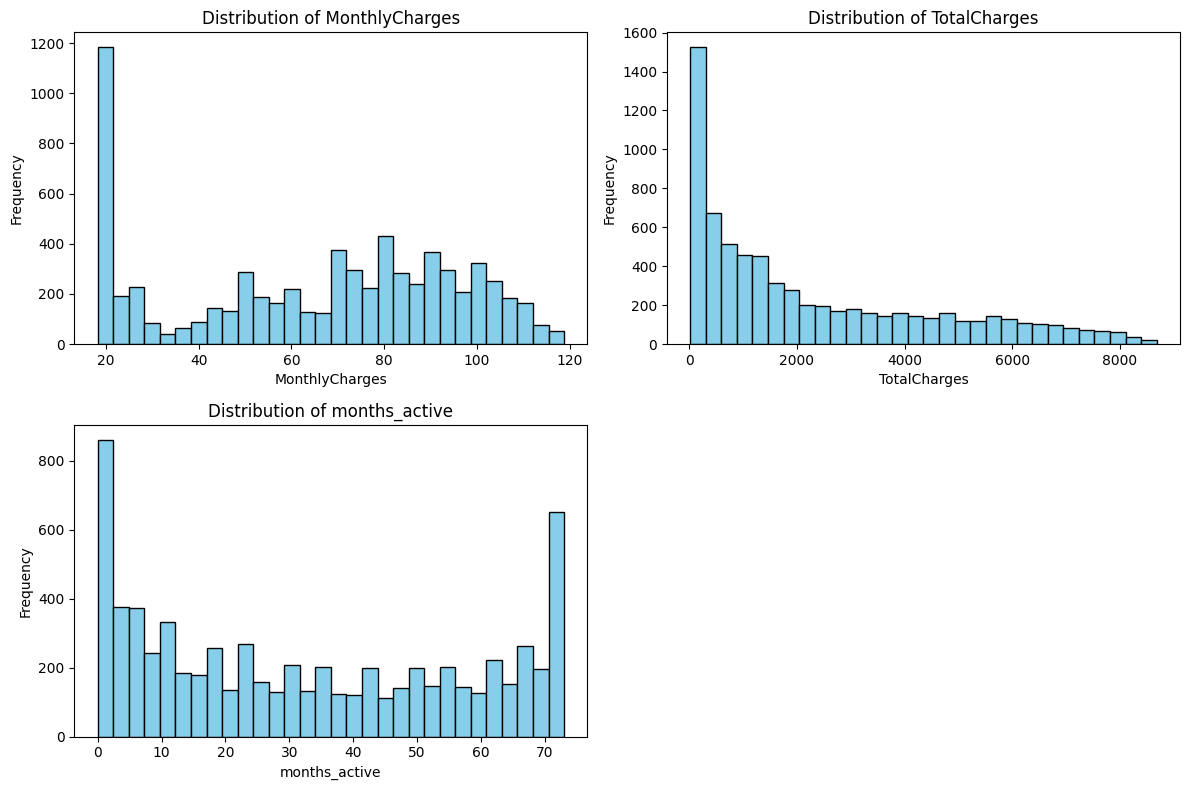

In [18]:
# Plot numerical features

numerical_features = ['MonthlyCharges', 'TotalCharges', 'months_active']

# Plotting distributions
plt.figure(figsize=(12, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    plt.hist(customer_info[feature], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [19]:
# Show correlation of numerical categories
customer_info.corr()

,MonthlyCharges,TotalCharges,SeniorCitizen,churned,months_active
MonthlyCharges,1.000000,0.651065,0.220173,0.193356,0.247754
TotalCharges,0.651065,1.000000,0.102411,-0.199484,0.825811
SeniorCitizen,0.220173,0.102411,1.000000,0.150889,0.016514
churned,0.193356,-0.199484,0.150889,1.000000,-0.352673
months_active,0.247754,0.825811,0.016514,-0.352673,1.000000


Monthly charges looks multimodal, with the largest cluster around the low end of charges. This likely reflects different pricing tiers.

For total charges, we can see that this is right-skewed, with most customers having low total charges. This feature is likely redundant with monthly charges and months active (it is highly correlated with months active), so we can drop this column for model training.

In [20]:
# Drop TotalCharges column
customer_info = customer_info.drop(columns=['TotalCharges'])

For months active, we see a U-shaped distribution. This is a strong churn predictor, and many customers appear to churn early while loyal customers tend to stay longer term. 

Now we'll take a look at categorical features.

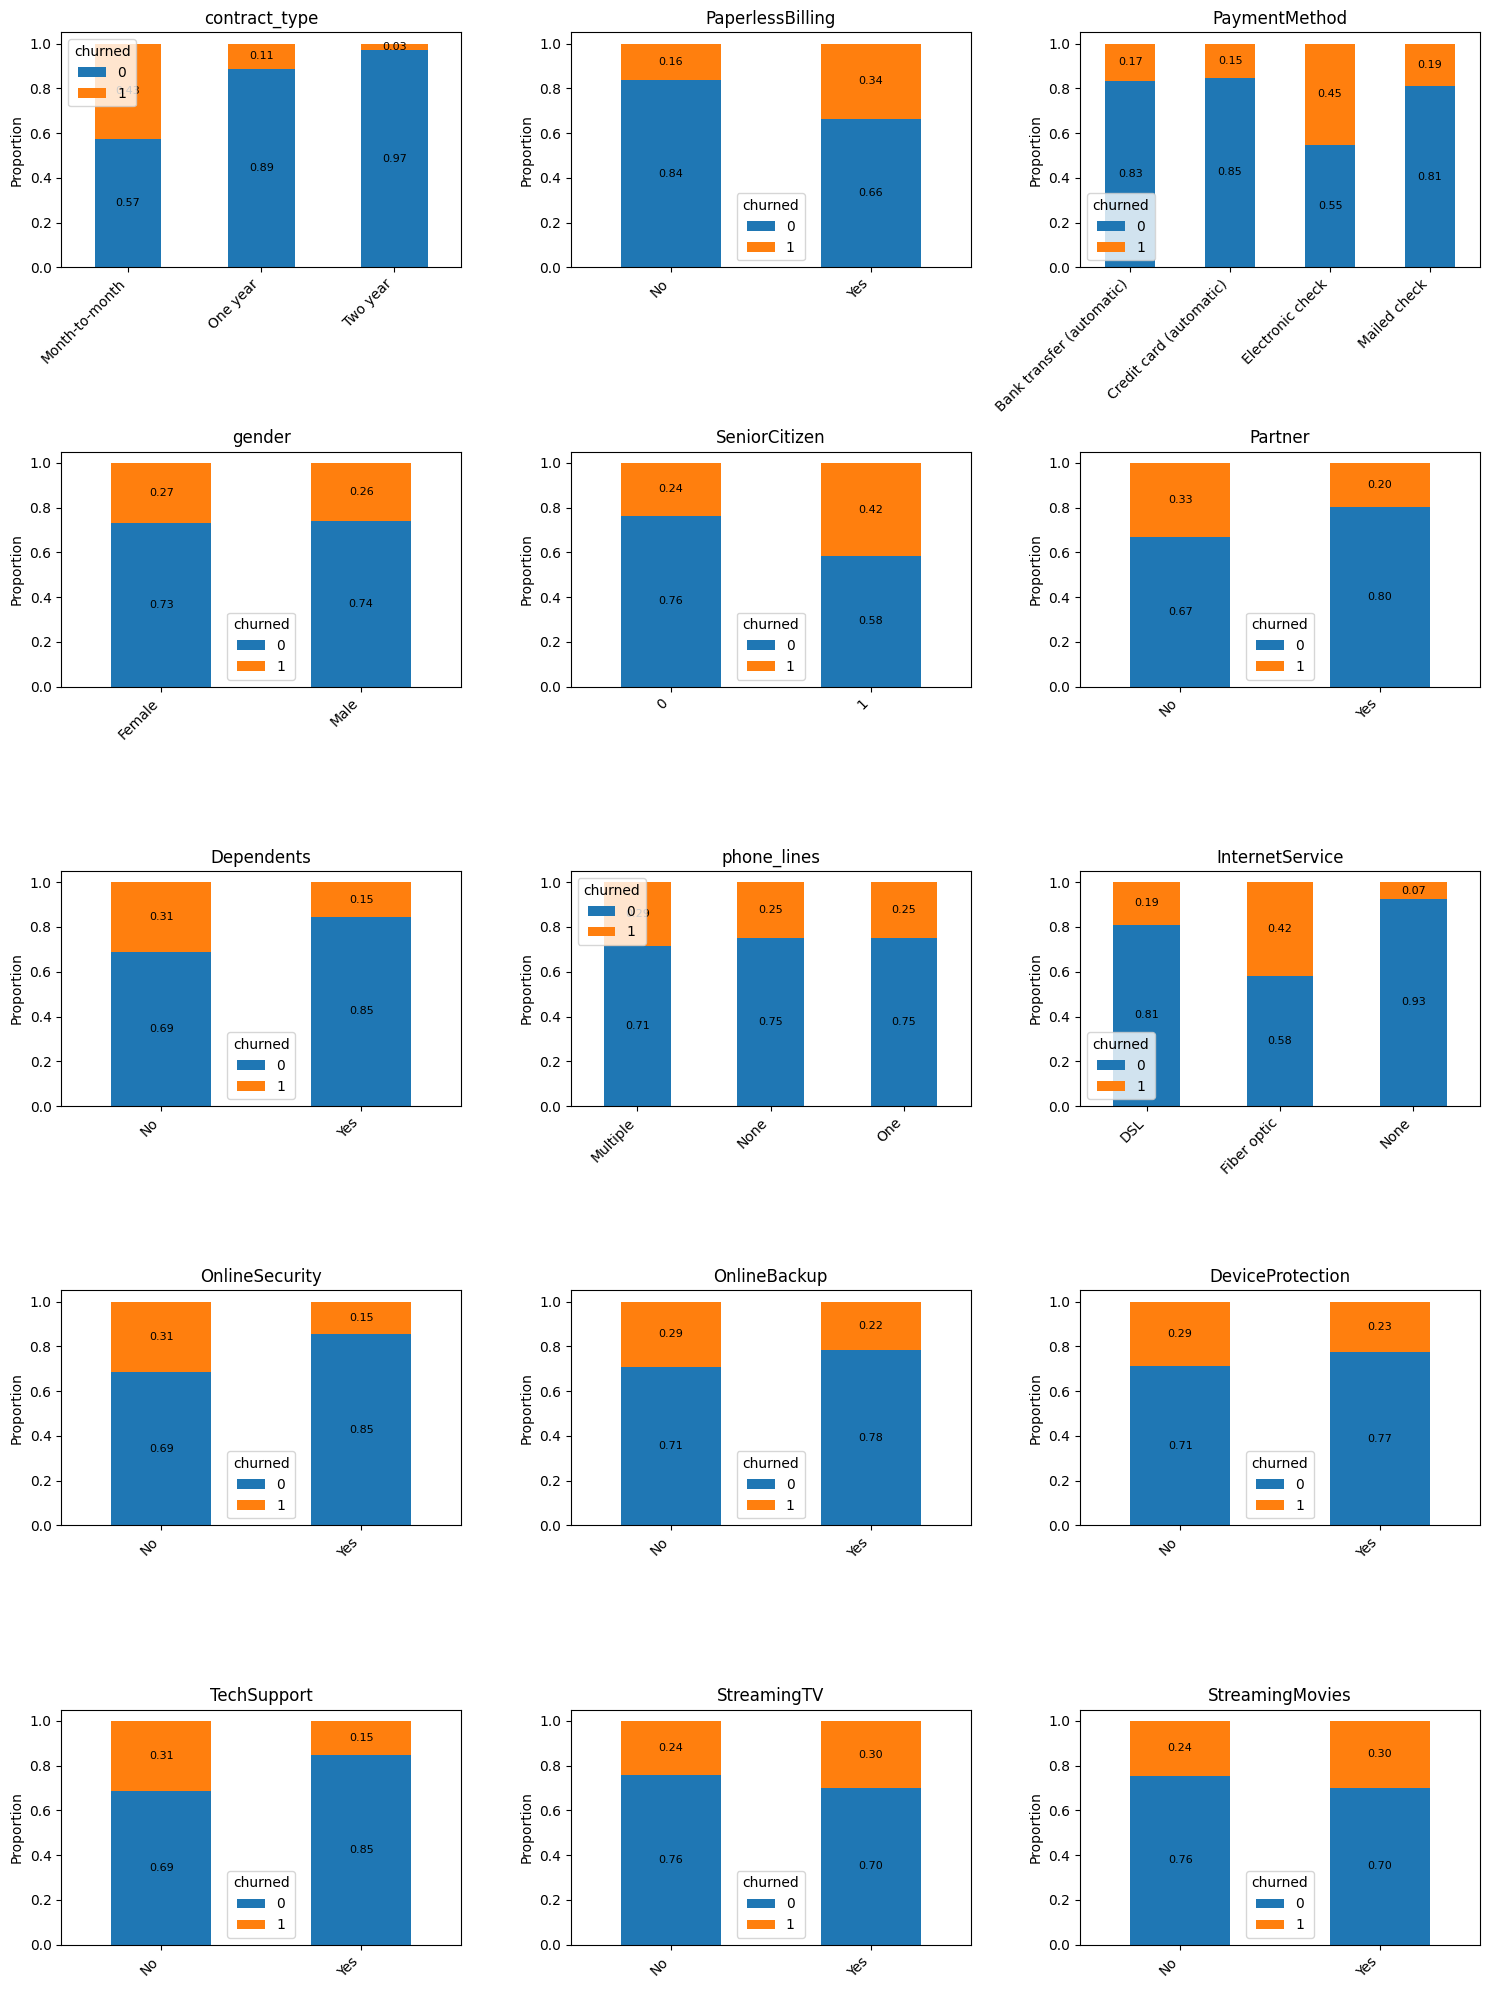

In [21]:
# Define categorical features
categorical_features = [
    'contract_type', 'PaperlessBilling', 'PaymentMethod', 'gender',
    'SeniorCitizen', 'Partner', 'Dependents', 'phone_lines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Dynamic grid setup
n = len(categorical_features)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

for i, feature in enumerate(categorical_features, 1):
    ax = plt.subplot(rows, cols, i)
    
    # Crosstab with percentages
    ct = pd.crosstab(
        customer_info[feature],
        customer_info['churned'],
        normalize='index'
    )
    
    ct.plot(kind='bar', stacked=True, ax=ax)
    
    plt.title(feature)
    plt.ylabel('Proportion')
    plt.xlabel('')
    plt.xticks(rotation=45, ha='right')
    
    # Add manual labels
    for j, (index, row) in enumerate(ct.iterrows()):
        cumulative = 0
        for k, value in enumerate(row):
            if value > 0:
                ax.text(
                    j, 
                    cumulative + value / 2, 
                    f'{value:.2f}', 
                    ha='center', 
                    va='center', 
                    fontsize=8
                )
                cumulative += value

plt.tight_layout()
plt.show()

We can see that contract type is very predictive, and very few 1 and 2 year contract holders churn. This does raise questions about 1 and 2 year contract holders churning at all--how are they churning if they are locked into a contract? These are likely outlier values due to involuntary churn (e.g., billing issues, death). We'll see what percentage of the dataset these outlier records account for. 

In [22]:
# Count rows with churn on 1 and 2 year contracts
count = (
    (customer_info['churned'] == 1) &
    (customer_info['contract_type'] != 'Month-to-month')
).sum()


print(count)

214


These values only comprise 3% of the dataset, which is not significant. It's also not that helpful to offer a discount to customers who are about to churn involuntarily, so dropping these records shouldn't affect the model's value for this task. 

In [23]:
# Drop outlier rows
customer_info = customer_info[
    ~(
        (customer_info['churned'] == 1) &
        (customer_info['contract_type'] != 'Month-to-month')
    )
]

Gender doesn't look very predictive and might cause noise in the model, so we'll drop it.

In [24]:
# Drop gender column
customer_info = customer_info.drop(columns=['gender'])

Overall, churn is strongly associated with low customer commitment (month-to-month contracts), low service adoption (lack of security and support add-ons), and manual payment behavior (electronic check). Customers with deeper product engagement and longer-term contracts exhibit significantly lower churn rates.

We'll also transform the Yes/No columns to 0/1 oso we can keep them as clean, binary integer columns versus creating too many dummy columns when encoding for model prep.

In [25]:
# Define binary columns
binary_cols = [
    'PaperlessBilling', 'Partner', 'Dependents',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Transform columns

customer_info[binary_cols] = (
    customer_info[binary_cols]
    .replace({
        'Yes': 1,
        'No': 0,
    })
    .astype(int)
)

Finally, we don't want the models to train on the values in the customerID column, but it would be useful to keep those values as metadata to know which customers to offer discounts to, so we'll set that column to the index.

In [26]:
# Set customerID to index
customer_info = customer_info.set_index('customerID')

Now that we've finished with data cleaning and feature engineering, we're ready for model training!

## Model Training

We are going to train five models for predicting customer churn: Random Forest, Logistic Regression, and three gradient boost models (Catboost, LightGBM, and XGBoost). Some of the models need feature scaling and encoding while some do not, so I'm going to do preprocessing and set up pipelines for each model to train.

We'll use OHE for Random Forest, Logistic Regression, XGBoost, and LightGBM, and native categorical handling for Catboost. None of the categorical columns have too many categories so this shouldn't create too many feature columns for the models to handle.

In [27]:
# Call info
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6829 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   contract_type     6829 non-null   object 
 1   PaperlessBilling  6829 non-null   int64  
 2   PaymentMethod     6829 non-null   object 
 3   MonthlyCharges    6829 non-null   float64
 4   SeniorCitizen     6829 non-null   int64  
 5   Partner           6829 non-null   int64  
 6   Dependents        6829 non-null   int64  
 7   phone_lines       6829 non-null   object 
 8   InternetService   6829 non-null   object 
 9   OnlineSecurity    6829 non-null   int64  
 10  OnlineBackup      6829 non-null   int64  
 11  DeviceProtection  6829 non-null   int64  
 12  TechSupport       6829 non-null   int64  
 13  StreamingTV       6829 non-null   int64  
 14  StreamingMovies   6829 non-null   int64  
 15  churned           6829 non-null   int64  
 16  months_active     6829 non-null 

In [28]:
# Identify categorical and numerical columns
categorical_features = ['contract_type', 'PaymentMethod','phone_lines','InternetService']

numerical_features = ['MonthlyCharges', 'months_active', 'PaperlessBilling', 'SeniorCitizen','Partner', 'Dependents',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies' ] 

# Split data
X = customer_info.drop('churned', axis=1)
y = customer_info['churned']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Logistic Regression preprocessing: scale numerical, OHE categorical
preprocess_log = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features)
])

# Tree/boosting preprocessing: no scaling, OHE categorical
preprocess_tree = ColumnTransformer([
    ("num", "passthrough", numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features)
])

# Logistic Regression pipeline
log_pipeline = Pipeline([
    ("preprocess", preprocess_log),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# XGBoost pipeline (using preprocess_tree)
xgb_pipeline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    ))
])


# LGBM Pipeline (using preprocess_tree)
lgbm_pipeline = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", LGBMClassifier(
        objective="binary",
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

Now we're ready to tune hyperparameters for each model. We'll use GridSearch to do this, and use roc_auc to score.

### Logistic Regression

In [29]:
# Define parameter grid
log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

# Set up GridSearch
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_grid = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit model
log_grid.fit(X_train, y_train)

# Validation score for best model
log_val_probs = log_grid.best_estimator_.predict_proba(X_val)[:, 1]
log_val_auc = roc_auc_score(y_val, log_val_probs)

print("Best Parameters:", log_grid.best_params_)
print("Training CV ROC AUC:", log_grid.best_score_)
print("Validation ROC AUC:", log_val_auc)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Training CV ROC AUC: 0.8950534861721755
Validation ROC AUC: 0.9051068340538743


### Random Forest

In [30]:
# Define parameter grid
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10, 20],
}

# Set up GridSearch
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit model
rf_grid.fit(X_train, y_train)

# Validation score for best model
rf_val_probs = rf_grid.best_estimator_.predict_proba(X_val)[:, 1]
rf_val_auc = roc_auc_score(y_val, rf_val_probs)

print("Best Parameters:", rf_grid.best_params_)
print("Training CV ROC AUC:", rf_grid.best_score_)
print("Validation ROC AUC:", rf_val_auc)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 200}
Training CV ROC AUC: 0.9051671464529629
Validation ROC AUC: 0.9104277519122049


### XGBoost

In [31]:
# Define parameter grid
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
}

# Set up GridSearch
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit model
xgb_grid.fit(X_train, y_train)

# Validation score for best model
xgb_val_probs = xgb_grid.best_estimator_.predict_proba(X_val)[:, 1]
xgb_val_auc = roc_auc_score(y_val, xgb_val_probs)

print("Best Parameters:", xgb_grid.best_params_)
print("Training CV ROC AUC:", xgb_grid.best_score_)
print("Validation ROC AUC:", xgb_val_auc)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/.venv/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/.venv/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/.venv/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClas

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200}
Training CV ROC AUC: 0.9392718574925423
Validation ROC AUC: 0.9491135267708679


### LightGBM

In [32]:
# Define parameter grid
lgbm_param_grid = {
    "model__n_estimators": [100, 200],
    "model__num_leaves": [15, 30],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [4, 6],
}

# Set up GridSearch
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lgbm_grid = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=lgbm_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit model
lgbm_grid.fit(X_train, y_train)

# Validation score for best model
lgbm_val_probs = lgbm_grid.best_estimator_.predict_proba(X_val)[:, 1]
lgbm_val_auc = roc_auc_score(y_val, lgbm_val_probs)

print("Best Parameters:", lgbm_grid.best_params_)
print("Training CV ROC AUC:", lgbm_grid.best_score_)
print("Validation ROC AUC:", lgbm_val_auc)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__num_leaves': 30}
Training CV ROC AUC: 0.9364816978125704
Validation ROC AUC: 0.9467492517459262


### Catboost

In [33]:
# Define model
cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    auto_class_weights="Balanced"
)

# Define parameter grid
cat_param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.05, 0.1],
}

# Set up GridSearch
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit model
cat_grid.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

# Validation score for best model
cat_val_probs = cat_grid.best_estimator_.predict_proba(X_val)[:, 1]
cat_val_auc = roc_auc_score(y_val, cat_val_probs)

print("Best Parameters:", cat_grid.best_params_)
print("Training CV ROC AUC:", cat_grid.best_score_)
print("Validation ROC AUC:", cat_val_auc)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}
Training CV ROC AUC: 0.9327063855288042
Validation ROC AUC: 0.94347564017293


## Model Analysis
As seen in the performance on the validation set, XGBoost was the best performing model. We'll run a final evaluation on this model using the test set. First, we'll refit preprocessing on the combined training and validation sets and then run the XGBoost model with the best parameters on the test set. 

In [34]:
# Combine training and validation sets
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

# Recreate final XGBoost pipeline with best parameters
final_xgb_model = clone(xgb_pipeline)
final_xgb_model.set_params(**xgb_grid.best_params_)

# Fit on combined training + validation data
final_xgb_model.fit(X_train_val, y_train_val)

# Predict probabilities on the test set
xgb_test_probs = final_xgb_model.predict_proba(X_test)[:, 1]

# Calculate final test ROC AUC
xgb_test_auc = roc_auc_score(y_test, xgb_test_probs)

print("Final XGBoost Test ROC AUC:", xgb_test_auc)

/.venv/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Final XGBoost Test ROC AUC: 0.9360379662981824


## Conclusion
After tuning hyperparameters and evaluating the final model on the test set, we can see the Logistic Regression model performed the worst, Random Forest performed slightly better, and the three gradient boosting models all performed significantly better with XGBoost showing the highest roc_auc score. Therefore, I recommend that Interconnect use XGBoost to predict customer churn so they may offer plan discounts to improve customer retention.

## Solution Report

For this task, I followed all the steps of my original work plan:

1. First, I finished data pipeline preparation. I completed data cleaning, including correcting data types and filling in null values, and then completed feature engineering, including adding new columns and dropping unecessary ones.
   
2. Next, I trained and tuned hyperparameters for a variety of machine learning models. I specifically explored Logistic Regression (primarily as a benchmark), Random Forest, and three gradient boosting models: CatBoost, LightGBM, and XGBoost.

3. Finally, I selected the model with the best hyperparameters as performing on the training and test sets, and performed a final evaluation on the validation set using ROC-AUC. I made a model recommendation for Interconnect based on this evaluation (XGBoost).

The main difficulty I encountered in this task was the need to prep the data differently to properly train the five different models. While some models required encoding of categorical features, others could handle these natively. Similarly, some models needed feature scaling while others did not. I managed to solve this by preprocessing and creating pipelines for the different models, so each model was training on the same dataset but in a bespoke form that worked for that model. 

In addition to preprocessing and pipeline creation, solving this task involved a few other key steps. First, joining the four different dataframes into one made one training set that could be fed to the models. Next, data cleaning and feature engineering based on EDA transformed the training data into a much more useful format that ultimately maximized model performance. Dropping unnecessary columns (e.g., gender) reduced noise, while adding new columns such as number of months the client was active calculated based on contract start and end dates provided useful predicitive variables for model training. 

Using GridSearch to tune hyperparameters for each model helped identify the best performing version of each type of model. Finally, combining the training and validation sets and running the final best performing model on the test set confirmed that the model was not overfitted and can be used reliably with new customer data. 

Ultimately, the final model I recommended for this task was XGBoost, with an ROC-AUC score of .94 on the test set.